In [ ]:
# Step 1: Setup working file directory

In [11]:
from pathlib import Path

In [13]:
data_folder = Path(r"C:\Users\eriat\Downloads\genes")

In [14]:
if data_folder.exists():
    print("Data folder found.")
    print(data_folder)
else:
    print("Data folder not found. Check the folder path.")

Data folder found.
C:\Users\eriat\Downloads\genes


In [15]:
txt_files = list(data_folder.glob("*.txt"))
tsv_files = list(data_folder.glob("*.tsv"))

all_files = txt_files + tsv_files

In [16]:
print("Number of files found:", len(all_files))

Number of files found: 24


In [17]:
for file in all_files:
    print(file.name)

Ah3_data_file.txt
Alli8_data_file.txt
Anap7c1_data_file.txt
App1l8_data_file.txt
Avon4_data_file.txt
Cairn3a2_data_file.txt
Cairn6_data_file.txt
Clach6_data_file.txt
Dsgt9a1_data_file.txt
Ever6b6_data_file.txt
Everr1_data_file.txt
Got9_data_file.txt
Ist3_data_file.txt
Ist9a2_data_file.txt
Ist9a7_data_file.txt
Ist9a_data_file.txt
Jams9r2_data_file.txt
Jok4a3_data_file.txt
K2_data_file.txt
Kl8_data_file.txt
Nect1c1_data_file.txt
Nect5r3_data_file.txt
Pear9a7_data_file.txt
Thxr_data_file.txt


In [ ]:
# Step 2: Load the tab-separated files into Python

In [18]:
import pandas as pd

In [19]:
first_file = all_files[0]

print(first_file.name)

Ah3_data_file.txt


In [20]:
first_df = pd.read_csv(first_file, sep="\t")

In [21]:
first_df.head()

,Gene,WildType.Sequence,Mutant.Sequence,mRNA.Expression.WT.Rep1,mRNA.Expression.WT.Rep2,mRNA.Expression.WT.Rep3,mRNA.Expression.Mut.Rep1,mRNA.Expression.Mut.Rep2,mRNA.Expression.Mut.Rep3,Protein.Expression.WT.Rep1,Protein.Expression.WT.Rep2,Protein.Expression.WT.Rep3,Protein.Expression.Mut.Rep1,Protein.Expression.Mut.Rep2,Protein.Expression.Mut.Rep3,CellViability.WT.Rep1,CellViability.WT.Rep2,CellViability.WT.Rep3,CellViability.Mut.Rep1,CellViability.Mut.Rep2,CellViability.Mut.Rep3
0,Ah3,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,3.183135e+08,26.177081,16.735333,3.183135e+08,27.769621,17.761754,11685,26722,37123,11693,26726,37133,0.261116,0.726898,0.633374,0.338555,0.750318,0.710077


In [22]:
print(first_df.shape)

(1, 21)


In [23]:
first_df.columns.tolist()

['Gene',
 'WildType.Sequence',
 'Mutant.Sequence',
 'mRNA.Expression.WT.Rep1',
 'mRNA.Expression.WT.Rep2',
 'mRNA.Expression.WT.Rep3',
 'mRNA.Expression.Mut.Rep1',
 'mRNA.Expression.Mut.Rep2',
 'mRNA.Expression.Mut.Rep3',
 'Protein.Expression.WT.Rep1',
 'Protein.Expression.WT.Rep2',
 'Protein.Expression.WT.Rep3',
 'Protein.Expression.Mut.Rep1',
 'Protein.Expression.Mut.Rep2',
 'Protein.Expression.Mut.Rep3',
 'CellViability.WT.Rep1',
 'CellViability.WT.Rep2',
 'CellViability.WT.Rep3',
 'CellViability.Mut.Rep1',
 'CellViability.Mut.Rep2',
 'CellViability.Mut.Rep3']

In [25]:
dataframes = {}

for file in all_files:
    df = pd.read_csv(file, sep="\t")
    dataframes[file.name] = df

In [26]:
print("Number of files loaded:", len(dataframes))

Number of files loaded: 24


In [27]:
for filename, df in dataframes.items():
    print(filename, df.shape)

Ah3_data_file.txt (1, 21)
Alli8_data_file.txt (1, 21)
Anap7c1_data_file.txt (1, 21)
App1l8_data_file.txt (1, 21)
Avon4_data_file.txt (1, 21)
Cairn3a2_data_file.txt (1, 21)
Cairn6_data_file.txt (1, 21)
Clach6_data_file.txt (1, 21)
Dsgt9a1_data_file.txt (1, 21)
Ever6b6_data_file.txt (1, 21)
Everr1_data_file.txt (1, 21)
Got9_data_file.txt (1, 21)
Ist3_data_file.txt (1, 21)
Ist9a2_data_file.txt (1, 21)
Ist9a7_data_file.txt (1, 21)
Ist9a_data_file.txt (1, 21)
Jams9r2_data_file.txt (1, 21)
Jok4a3_data_file.txt (1, 21)
K2_data_file.txt (1, 21)
Kl8_data_file.txt (1, 21)
Nect1c1_data_file.txt (1, 21)
Nect5r3_data_file.txt (1, 21)
Pear9a7_data_file.txt (1, 21)
Thxr_data_file.txt (1, 21)


In [ ]:
# Step 3: Extract wildtype vs mutant sequences for comparison.

In [28]:
example_name = list(dataframes.keys())[0]

print("Example file:", example_name)

dataframes[example_name].head()

Example file: Ah3_data_file.txt


,Gene,WildType.Sequence,Mutant.Sequence,mRNA.Expression.WT.Rep1,mRNA.Expression.WT.Rep2,mRNA.Expression.WT.Rep3,mRNA.Expression.Mut.Rep1,mRNA.Expression.Mut.Rep2,mRNA.Expression.Mut.Rep3,Protein.Expression.WT.Rep1,Protein.Expression.WT.Rep2,Protein.Expression.WT.Rep3,Protein.Expression.Mut.Rep1,Protein.Expression.Mut.Rep2,Protein.Expression.Mut.Rep3,CellViability.WT.Rep1,CellViability.WT.Rep2,CellViability.WT.Rep3,CellViability.Mut.Rep1,CellViability.Mut.Rep2,CellViability.Mut.Rep3
0,Ah3,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,3.183135e+08,26.177081,16.735333,3.183135e+08,27.769621,17.761754,11685,26722,37123,11693,26726,37133,0.261116,0.726898,0.633374,0.338555,0.750318,0.710077


In [29]:
example_name = list(dataframes.keys())[0]
example_df = dataframes[example_name]

print(example_name)
print(example_df[["Gene", "WildType.Sequence", "Mutant.Sequence"]])

Ah3_data_file.txt
  Gene                                  WildType.Sequence  \
0  Ah3  TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...   

                                     Mutant.Sequence  
0  TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...  


In [30]:
gene_name = example_df["Gene"].iloc[0]
wildtype_sequence = example_df["WildType.Sequence"].iloc[0]
mutant_sequence = example_df["Mutant.Sequence"].iloc[0]

print("Gene:", gene_name)
print("Wildtype sequence:", wildtype_sequence)
print("Mutant sequence:", mutant_sequence)

Gene: Ah3
Wildtype sequence: TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCAAGCAGTCGGGCTTCAGGAACACCGTAGGCTTCTTTTGCCGCAGTTGGGCTCTACAACGGCGCAGAAAATGTACGGTCATAAACGCTGCACCTATAACCAACATCGTCACTAACCCTTTTGCGGGTCGTAGATTAAAAACGCTGACGGCAGTACGGCGTCTCTAGACGCCCGGGGGCAAATAAACATGGTCGATCAATGACGCCGTCAATCAACGGCAATAAAGTAGTTGGCCAGGTGCGAGTCACATCGGTGTCGAGTGTTCTTCCTCTCGCGTCCCGATGCGCAGCACGACTTCAAAGGTATTGGTTCCGTCATGCAACGTCGGATATCGAGTCACACTGTATTACCAAATTCTACTTTACCAGAGATATATAAGATGGAATACGCTATTTGTCACATAGTGTCCGATAACGTTGAAGTTAGATACATGCCGTACTGTCCCGTTTTTAAAGCCTGTCTTTGCGAGTGATCCAGTTGGTGCCGATAGTCATATTTCGCCCACAGAATCCCTTTACTGCACCGTCAGACAGTGAAATAGCAGGCGAAGCTAGGGTCCATTTTTTTTCGTATGCGTCGGGTACGCCGGAGGACGCGCAAGCTGCTTTTAGTCGAGGTCAACTTATGTCACGCGTGCTTCGTCTGCATTCCAGGATTAACTTCTGCACATACACAGAAAGCAAGAATGCCAAACGCATCCTTCCTTACCGGCTAGTGAGCCTACGCTTTCGCTGCTCTGACCTACTTCCTGGCGTTATGAGGGCTCCTGGCTCCTGCGACGGCGATGCCGTGTGGTACCAATCAAACTGCGGGTAGGTTCGAGGTTCGCATCAGACTAACCTCCGTTCCCACACGGGTTATTACACGAATAACGGCGACTCCATGGTCGCTCAACCCCCTTACAAGATTTAAATAAATGAAGCTTTAG

In [31]:
print("Wildtype sequence length:", len(wildtype_sequence))
print("Mutant sequence length:", len(mutant_sequence))

Wildtype sequence length: 1456
Mutant sequence length: 1456


In [32]:
sequence_records = []

for filename, df in dataframes.items():
    gene_name = df["Gene"].iloc[0]
    wildtype_sequence = df["WildType.Sequence"].iloc[0]
    mutant_sequence = df["Mutant.Sequence"].iloc[0]
    
    sequence_records.append({
        "Filename": filename,
        "Gene": gene_name,
        "WildType.Sequence": wildtype_sequence,
        "Mutant.Sequence": mutant_sequence
    })

In [33]:
sequence_df = pd.DataFrame(sequence_records)

sequence_df.head()

,Filename,Gene,WildType.Sequence,Mutant.Sequence
0,Ah3_data_file.txt,Ah3,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...
1,Alli8_data_file.txt,Alli8,TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...,TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...
2,Anap7c1_data_file.txt,Anap7c1,GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...,GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...
3,App1l8_data_file.txt,App1l8,ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...,ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...
4,Avon4_data_file.txt,Avon4,TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...,TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...


In [34]:
print("Number of sequence records:", len(sequence_df))

Number of sequence records: 24


In [35]:
sequence_df["WildType.Length"] = sequence_df["WildType.Sequence"].str.len()
sequence_df["Mutant.Length"] = sequence_df["Mutant.Sequence"].str.len()

sequence_df.head()

,Filename,Gene,WildType.Sequence,Mutant.Sequence,WildType.Length,Mutant.Length
0,Ah3_data_file.txt,Ah3,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,1456,1456
1,Alli8_data_file.txt,Alli8,TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...,TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...,1312,1312
2,Anap7c1_data_file.txt,Anap7c1,GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...,GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...,1312,1312
3,App1l8_data_file.txt,App1l8,ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...,ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...,1312,1314
4,Avon4_data_file.txt,Avon4,TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...,TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...,1354,1361


In [36]:
sequence_df["Same.Length"] = sequence_df["WildType.Length"] == sequence_df["Mutant.Length"]

sequence_df[["Gene", "WildType.Length", "Mutant.Length", "Same.Length"]]

,Gene,WildType.Length,Mutant.Length,Same.Length
0,Ah3,1456,1456,True
1,Alli8,1312,1312,True
2,Anap7c1,1312,1312,True
3,App1l8,1312,1314,False
4,Avon4,1354,1361,False
5,Cairn3a2,1381,1381,True
6,Cairn6,1342,1342,True
7,Clach6,1366,1366,True
8,Dsgt9a1,1369,1376,False
9,Ever6b6,1309,1307,False


In [37]:
sequence_df[sequence_df["Same.Length"] == False]

,Filename,Gene,WildType.Sequence,Mutant.Sequence,WildType.Length,Mutant.Length,Same.Length
3,App1l8_data_file.txt,App1l8,ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...,ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...,1312,1314,False
4,Avon4_data_file.txt,Avon4,TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...,TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...,1354,1361,False
8,Dsgt9a1_data_file.txt,Dsgt9a1,ATAATCGCTGGTGTACTTCAAGTTACGACTTGAGTACGCATATCCA...,ATAATCGCTGGTGTACTTCAAGTTACGACTTGAGTACGCATATCCA...,1369,1376,False
9,Ever6b6_data_file.txt,Ever6b6,AAGTTATTCTACGGGCCCTCTATTGAATAGATAACCCAGGGGCGTG...,AAGTTATTCTACGGGCCCTCTATTGAATAGATAACCCAGGGGCGTG...,1309,1307,False
10,Everr1_data_file.txt,Everr1,ATCTAGATGTGAATATATATATTCAAAGTTATATATGAAGTGCCCT...,ATCTAGATGTGAATATATATATTCAAAGTTATATATGAAGTGCCCT...,1369,1378,False
11,Got9_data_file.txt,Got9,TTAGGTCCCTCTTCTCAAGATGAGCCTTACTCGCGGTCTATGGGGG...,TTAGGTCCCTCTTCTCAAGATGAGCCTTACTCGCGGTCTATGGGGG...,1333,1336,False
12,Ist3_data_file.txt,Ist3,ATCAATAATGGGACGAAGCGTTAGCGTCTGCTGCGCTATCGTCATA...,ATCAATAATGGGACGAAGCGTTAGCGTCTGCTGCGCTATCGTCATA...,1363,1357,False
13,Ist9a2_data_file.txt,Ist9a2,TTTGTTGATATCTTCGGGAGGGCTAGATGGGACCAAGAGGGTTCCG...,TCACGTTAATACCAGGCCCTGGTCATACCACGAGCAAGAGATACGA...,1387,391,False
15,Ist9a_data_file.txt,Ist9a,AATATATATATCCGCGATAGATATAATTTTTCTGTGTGCCAGTCGC...,AATATATATATCCGCGATAGATATAATGTGTGCCAGTCGCTCCTAC...,1369,1363,False
16,Jams9r2_data_file.txt,Jams9r2,AACCTGGTAGTTCCAAACAGCGATCATAAAATACTTCTGTTGTGCC...,AACCTGGTAGTTCCAAACAGCGATCATAAAATACTTCTGTTGTGCC...,1348,1346,False


In [38]:
sequence_df.to_csv("sequence_summary.csv", index=False)

In [39]:
# Step 4: Compute sequence differences/mutation counts between wildtype and mutant sequences.

In [40]:
example_row = sequence_df.iloc[0]

gene = example_row["Gene"]
wt_seq = example_row["WildType.Sequence"]
mut_seq = example_row["Mutant.Sequence"]

print("Gene:", gene)
print("WT sequence:", wt_seq)
print("Mutant sequence:", mut_seq)

Gene: Ah3
WT sequence: TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCAAGCAGTCGGGCTTCAGGAACACCGTAGGCTTCTTTTGCCGCAGTTGGGCTCTACAACGGCGCAGAAAATGTACGGTCATAAACGCTGCACCTATAACCAACATCGTCACTAACCCTTTTGCGGGTCGTAGATTAAAAACGCTGACGGCAGTACGGCGTCTCTAGACGCCCGGGGGCAAATAAACATGGTCGATCAATGACGCCGTCAATCAACGGCAATAAAGTAGTTGGCCAGGTGCGAGTCACATCGGTGTCGAGTGTTCTTCCTCTCGCGTCCCGATGCGCAGCACGACTTCAAAGGTATTGGTTCCGTCATGCAACGTCGGATATCGAGTCACACTGTATTACCAAATTCTACTTTACCAGAGATATATAAGATGGAATACGCTATTTGTCACATAGTGTCCGATAACGTTGAAGTTAGATACATGCCGTACTGTCCCGTTTTTAAAGCCTGTCTTTGCGAGTGATCCAGTTGGTGCCGATAGTCATATTTCGCCCACAGAATCCCTTTACTGCACCGTCAGACAGTGAAATAGCAGGCGAAGCTAGGGTCCATTTTTTTTCGTATGCGTCGGGTACGCCGGAGGACGCGCAAGCTGCTTTTAGTCGAGGTCAACTTATGTCACGCGTGCTTCGTCTGCATTCCAGGATTAACTTCTGCACATACACAGAAAGCAAGAATGCCAAACGCATCCTTCCTTACCGGCTAGTGAGCCTACGCTTTCGCTGCTCTGACCTACTTCCTGGCGTTATGAGGGCTCCTGGCTCCTGCGACGGCGATGCCGTGTGGTACCAATCAAACTGCGGGTAGGTTCGAGGTTCGCATCAGACTAACCTCCGTTCCCACACGGGTTATTACACGAATAACGGCGACTCCATGGTCGCTCAACCCCCTTACAAGATTTAAATAAATGAAGCTTTAGTGATCC

In [41]:
for position, (wt_base, mut_base) in enumerate(zip(wt_seq, mut_seq), start=1):
    if wt_base != mut_base:
        print(position, wt_base, ">", mut_base)

735 A > T


In [42]:
mutation_count = 0

for wt_base, mut_base in zip(wt_seq, mut_seq):
    if wt_base != mut_base:
        mutation_count += 1

print("Mutation count:", mutation_count)

Mutation count: 1


In [43]:
mutation_positions = []

for position, (wt_base, mut_base) in enumerate(zip(wt_seq, mut_seq), start=1):
    if wt_base != mut_base:
        mutation_positions.append(f"{position}:{wt_base}>{mut_base}")

print(mutation_positions)

['735:A>T']


In [44]:
mutation_details = "; ".join(mutation_positions)

print(mutation_details)

735:A>T


In [45]:
def compare_sequences(wt_seq, mut_seq):
    mutation_positions = []
    
    for position, (wt_base, mut_base) in enumerate(zip(wt_seq, mut_seq), start=1):
        if wt_base != mut_base:
            mutation_positions.append(f"{position}:{wt_base}>{mut_base}")
    
    mutation_count = len(mutation_positions)
    mutation_details = "; ".join(mutation_positions)
    
    return mutation_count, mutation_details

In [46]:
count, details = compare_sequences(wt_seq, mut_seq)

print("Gene:", gene)
print("Mutation count:", count)
print("Mutation details:", details)

Gene: Ah3
Mutation count: 1
Mutation details: 735:A>T


In [47]:
mutation_counts = []
mutation_details_list = []

for index, row in sequence_df.iterrows():
    wt_seq = row["WildType.Sequence"]
    mut_seq = row["Mutant.Sequence"]
    
    count, details = compare_sequences(wt_seq, mut_seq)
    
    mutation_counts.append(count)
    mutation_details_list.append(details)

In [48]:
sequence_df["Mutation.Count"] = mutation_counts
sequence_df["Mutation.Details"] = mutation_details_list

sequence_df.head()

,Filename,Gene,WildType.Sequence,Mutant.Sequence,WildType.Length,Mutant.Length,Same.Length,Mutation.Count,Mutation.Details
0,Ah3_data_file.txt,Ah3,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,1456,1456,True,1,735:A>T
1,Alli8_data_file.txt,Alli8,TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...,TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...,1312,1312,True,1,253:A>T
2,Anap7c1_data_file.txt,Anap7c1,GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...,GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...,1312,1312,True,1,495:T>G
3,App1l8_data_file.txt,App1l8,ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...,ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...,1312,1314,False,403,764:G>T; 765:G>C; 767:A>G; 769:T>A; 770:T>G; 7...
4,Avon4_data_file.txt,Avon4,TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...,TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...,1354,1361,False,718,386:G>T; 387:C>A; 388:C>T; 389:C>A; 391:C>T; 3...


In [49]:
sequence_df[["Gene", "Mutation.Count", "Mutation.Details"]]

,Gene,Mutation.Count,Mutation.Details
0,Ah3,1,735:A>T
1,Alli8,1,253:A>T
2,Anap7c1,1,495:T>G
3,App1l8,403,764:G>T; 765:G>C; 767:A>G; 769:T>A; 770:T>G; 7...
4,Avon4,718,386:G>T; 387:C>A; 388:C>T; 389:C>A; 391:C>T; 3...
5,Cairn3a2,1,462:T>G
6,Cairn6,1,121:C>G
7,Clach6,1,814:C>T
8,Dsgt9a1,252,1003:C>T; 1007:G>A; 1008:A>T; 1009:T>A; 1010:G...
9,Ever6b6,635,453:T>G; 454:G>A; 455:G>C; 456:A>C; 458:C>A; 4...


In [50]:
sequence_df.sort_values("Mutation.Count", ascending=False)[
    ["Gene", "Mutation.Count", "Mutation.Details"]
]

,Gene,Mutation.Count,Mutation.Details
15,Ist9a,1013,28:T>G; 30:T>G; 32:C>G; 33:T>C; 34:G>C; 35:T>A...
21,Nect5r3,947,54:C>T; 55:C>A; 57:T>G; 58:T>A; 62:C>T; 64:A>G...
22,Pear9a7,870,129:C>A; 134:G>C; 135:C>G; 136:G>C; 138:C>A; 1...
12,Ist3,739,351:C>T; 352:C>A; 353:T>C; 354:C>T; 356:G>C; 3...
4,Avon4,718,386:G>T; 387:C>A; 388:C>T; 389:C>A; 391:C>T; 3...
16,Jams9r2,714,422:T>A; 423:A>T; 424:A>C; 425:T>A; 426:C>A; 4...
9,Ever6b6,635,453:T>G; 454:G>A; 455:G>C; 456:A>C; 458:C>A; 4...
20,Nect1c1,621,490:T>A; 493:A>C; 495:A>T; 496:A>G; 497:T>G; 4...
11,Got9,461,706:A>T; 707:A>G; 708:T>A; 710:G>A; 711:A>T; 7...
3,App1l8,403,764:G>T; 765:G>C; 767:A>G; 769:T>A; 770:T>G; 7...


In [51]:
sequence_df.to_csv("sequence_mutation_summary.csv", index=False)

In [52]:
# Step 6: Calculate mean mRNA expression for WT and mutant across the 3 replicates.

In [53]:
example_name = list(dataframes.keys())[0]
example_df = dataframes[example_name]

print(example_name)
example_df.head()

Ah3_data_file.txt


,Gene,WildType.Sequence,Mutant.Sequence,mRNA.Expression.WT.Rep1,mRNA.Expression.WT.Rep2,mRNA.Expression.WT.Rep3,mRNA.Expression.Mut.Rep1,mRNA.Expression.Mut.Rep2,mRNA.Expression.Mut.Rep3,Protein.Expression.WT.Rep1,Protein.Expression.WT.Rep2,Protein.Expression.WT.Rep3,Protein.Expression.Mut.Rep1,Protein.Expression.Mut.Rep2,Protein.Expression.Mut.Rep3,CellViability.WT.Rep1,CellViability.WT.Rep2,CellViability.WT.Rep3,CellViability.Mut.Rep1,CellViability.Mut.Rep2,CellViability.Mut.Rep3
0,Ah3,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,3.183135e+08,26.177081,16.735333,3.183135e+08,27.769621,17.761754,11685,26722,37123,11693,26726,37133,0.261116,0.726898,0.633374,0.338555,0.750318,0.710077


In [54]:
mrna_wt_cols = [
    "mRNA.Expression.WT.Rep1",
    "mRNA.Expression.WT.Rep2",
    "mRNA.Expression.WT.Rep3"
]

print(mrna_wt_cols)

['mRNA.Expression.WT.Rep1', 'mRNA.Expression.WT.Rep2', 'mRNA.Expression.WT.Rep3']


In [56]:
mrna_mut_cols = [
    "mRNA.Expression.Mut.Rep1",
    "mRNA.Expression.Mut.Rep2",
    "mRNA.Expression.Mut.Rep3"
]

print(mrna_mut_cols)

['mRNA.Expression.Mut.Rep1', 'mRNA.Expression.Mut.Rep2', 'mRNA.Expression.Mut.Rep3']


In [57]:
example_df[["Gene"] + mrna_wt_cols + mrna_mut_cols]

,Gene,mRNA.Expression.WT.Rep1,mRNA.Expression.WT.Rep2,mRNA.Expression.WT.Rep3,mRNA.Expression.Mut.Rep1,mRNA.Expression.Mut.Rep2,mRNA.Expression.Mut.Rep3
0,Ah3,3.183135e+08,26.177081,16.735333,3.183135e+08,27.769621,17.761754


In [58]:
mrna_wt_mean = example_df[mrna_wt_cols].mean(axis=1).iloc[0]

print("WT mRNA mean:", mrna_wt_mean)

WT mRNA mean: 106104500.41802746


In [59]:
mrna_mut_mean = example_df[mrna_mut_cols].mean(axis=1).iloc[0]

print("Mutant mRNA mean:", mrna_mut_mean)

Mutant mRNA mean: 106104501.50114878


In [60]:
gene_name = example_df["Gene"].iloc[0]

print("Gene:", gene_name)
print("WT mRNA mean:", mrna_wt_mean)
print("Mutant mRNA mean:", mrna_mut_mean)

Gene: Ah3
WT mRNA mean: 106104500.41802746
Mutant mRNA mean: 106104501.50114878


In [61]:
mrna_records = []

for filename, df in dataframes.items():
    gene_name = df["Gene"].iloc[0]
    
    mrna_wt_mean = df[mrna_wt_cols].mean(axis=1).iloc[0]
    mrna_mut_mean = df[mrna_mut_cols].mean(axis=1).iloc[0]
    
    mrna_records.append({
        "Filename": filename,
        "Gene": gene_name,
        "mRNA.WT.Mean": mrna_wt_mean,
        "mRNA.Mut.Mean": mrna_mut_mean
    })

In [62]:
mrna_df = pd.DataFrame(mrna_records)

mrna_df.head()

,Filename,Gene,mRNA.WT.Mean,mRNA.Mut.Mean
0,Ah3_data_file.txt,Ah3,1.061045e+08,1.061045e+08
1,Alli8_data_file.txt,Alli8,2.765717e+01,2.692833e+01
2,Anap7c1_data_file.txt,Anap7c1,9.957710e+00,-3.957048e+01
3,App1l8_data_file.txt,App1l8,4.057949e+00,3.632353e+00
4,Avon4_data_file.txt,Avon4,2.512790e+00,3.958356e+00


In [63]:
print("Number of genes in mRNA table:", len(mrna_df))

Number of genes in mRNA table: 24


In [64]:
mrna_df

,Filename,Gene,mRNA.WT.Mean,mRNA.Mut.Mean
0,Ah3_data_file.txt,Ah3,1.061045e+08,1.061045e+08
1,Alli8_data_file.txt,Alli8,2.765717e+01,2.692833e+01
2,Anap7c1_data_file.txt,Anap7c1,9.957710e+00,-3.957048e+01
3,App1l8_data_file.txt,App1l8,4.057949e+00,3.632353e+00
4,Avon4_data_file.txt,Avon4,2.512790e+00,3.958356e+00
5,Cairn3a2_data_file.txt,Cairn3a2,2.536683e+01,2.574975e+01
6,Cairn6_data_file.txt,Cairn6,1.757151e+03,1.757414e+03
7,Clach6_data_file.txt,Clach6,8.647071e+00,7.966945e+00
8,Dsgt9a1_data_file.txt,Dsgt9a1,3.790932e+01,4.167821e+01
9,Ever6b6_data_file.txt,Ever6b6,1.059454e+06,1.059454e+06


In [66]:
mrna_df.to_csv("mrna_expression_summary.csv", index=False)

In [67]:
# Step 7: Calculate mean protein expression for WT and mutant across the 3 replicates.

In [68]:
example_name = list(dataframes.keys())[0]
example_df = dataframes[example_name]

print(example_name)
example_df.head()

Ah3_data_file.txt


,Gene,WildType.Sequence,Mutant.Sequence,mRNA.Expression.WT.Rep1,mRNA.Expression.WT.Rep2,mRNA.Expression.WT.Rep3,mRNA.Expression.Mut.Rep1,mRNA.Expression.Mut.Rep2,mRNA.Expression.Mut.Rep3,Protein.Expression.WT.Rep1,Protein.Expression.WT.Rep2,Protein.Expression.WT.Rep3,Protein.Expression.Mut.Rep1,Protein.Expression.Mut.Rep2,Protein.Expression.Mut.Rep3,CellViability.WT.Rep1,CellViability.WT.Rep2,CellViability.WT.Rep3,CellViability.Mut.Rep1,CellViability.Mut.Rep2,CellViability.Mut.Rep3
0,Ah3,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,3.183135e+08,26.177081,16.735333,3.183135e+08,27.769621,17.761754,11685,26722,37123,11693,26726,37133,0.261116,0.726898,0.633374,0.338555,0.750318,0.710077


In [69]:
protein_wt_cols = [
    "Protein.Expression.WT.Rep1",
    "Protein.Expression.WT.Rep2",
    "Protein.Expression.WT.Rep3"
]

print(protein_wt_cols)

['Protein.Expression.WT.Rep1', 'Protein.Expression.WT.Rep2', 'Protein.Expression.WT.Rep3']


In [70]:
protein_mut_cols = [
    "Protein.Expression.Mut.Rep1",
    "Protein.Expression.Mut.Rep2",
    "Protein.Expression.Mut.Rep3"
]

print(protein_mut_cols)

['Protein.Expression.Mut.Rep1', 'Protein.Expression.Mut.Rep2', 'Protein.Expression.Mut.Rep3']


In [71]:
example_df[["Gene"] + protein_wt_cols + protein_mut_cols]

,Gene,Protein.Expression.WT.Rep1,Protein.Expression.WT.Rep2,Protein.Expression.WT.Rep3,Protein.Expression.Mut.Rep1,Protein.Expression.Mut.Rep2,Protein.Expression.Mut.Rep3
0,Ah3,11685,26722,37123,11693,26726,37133


In [72]:
protein_wt_mean = example_df[protein_wt_cols].mean(axis=1).iloc[0]

print("WT protein mean:", protein_wt_mean)

WT protein mean: 25176.666666666668


In [73]:
protein_mut_mean = example_df[protein_mut_cols].mean(axis=1).iloc[0]

print("Mutant protein mean:", protein_mut_mean)

Mutant protein mean: 25184.0


In [74]:
gene_name = example_df["Gene"].iloc[0]

print("Gene:", gene_name)
print("WT protein mean:", protein_wt_mean)
print("Mutant protein mean:", protein_mut_mean)

Gene: Ah3
WT protein mean: 25176.666666666668
Mutant protein mean: 25184.0


In [75]:
protein_records = []

for filename, df in dataframes.items():
    gene_name = df["Gene"].iloc[0]
    
    protein_wt_mean = df[protein_wt_cols].mean(axis=1).iloc[0]
    protein_mut_mean = df[protein_mut_cols].mean(axis=1).iloc[0]
    
    protein_records.append({
        "Filename": filename,
        "Gene": gene_name,
        "Protein.WT.Mean": protein_wt_mean,
        "Protein.Mut.Mean": protein_mut_mean
    })

In [76]:
protein_df = pd.DataFrame(protein_records)

protein_df.head()

,Filename,Gene,Protein.WT.Mean,Protein.Mut.Mean
0,Ah3_data_file.txt,Ah3,25176.666667,25184.000000
1,Alli8_data_file.txt,Alli8,20556.333333,20565.333333
2,Anap7c1_data_file.txt,Anap7c1,21147.666667,10071.333333
3,App1l8_data_file.txt,App1l8,26965.333333,26974.000000
4,Avon4_data_file.txt,Avon4,35318.333333,55350.000000


In [77]:
print("Number of genes in protein table:", len(protein_df))

Number of genes in protein table: 24


In [79]:
#protein_df

In [81]:
protein_df.to_csv("protein_expression_summary.csv", index=False)

In [82]:
# Step 8: Calculate mean cell viability for WT and mutant across the 3 replicates

In [83]:
example_name = list(dataframes.keys())[0]
example_df = dataframes[example_name]

print(example_name)
example_df.head()

Ah3_data_file.txt


,Gene,WildType.Sequence,Mutant.Sequence,mRNA.Expression.WT.Rep1,mRNA.Expression.WT.Rep2,mRNA.Expression.WT.Rep3,mRNA.Expression.Mut.Rep1,mRNA.Expression.Mut.Rep2,mRNA.Expression.Mut.Rep3,Protein.Expression.WT.Rep1,Protein.Expression.WT.Rep2,Protein.Expression.WT.Rep3,Protein.Expression.Mut.Rep1,Protein.Expression.Mut.Rep2,Protein.Expression.Mut.Rep3,CellViability.WT.Rep1,CellViability.WT.Rep2,CellViability.WT.Rep3,CellViability.Mut.Rep1,CellViability.Mut.Rep2,CellViability.Mut.Rep3
0,Ah3,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,3.183135e+08,26.177081,16.735333,3.183135e+08,27.769621,17.761754,11685,26722,37123,11693,26726,37133,0.261116,0.726898,0.633374,0.338555,0.750318,0.710077


In [84]:
viability_wt_cols = [
    "CellViability.WT.Rep1",
    "CellViability.WT.Rep2",
    "CellViability.WT.Rep3"
]

print(viability_wt_cols)

['CellViability.WT.Rep1', 'CellViability.WT.Rep2', 'CellViability.WT.Rep3']


In [85]:
viability_mut_cols = [
    "CellViability.Mut.Rep1",
    "CellViability.Mut.Rep2",
    "CellViability.Mut.Rep3"
]

print(viability_mut_cols)

['CellViability.Mut.Rep1', 'CellViability.Mut.Rep2', 'CellViability.Mut.Rep3']


In [86]:
example_df[["Gene"] + viability_wt_cols + viability_mut_cols]

,Gene,CellViability.WT.Rep1,CellViability.WT.Rep2,CellViability.WT.Rep3,CellViability.Mut.Rep1,CellViability.Mut.Rep2,CellViability.Mut.Rep3
0,Ah3,0.261116,0.726898,0.633374,0.338555,0.750318,0.710077


In [87]:
viability_wt_mean = example_df[viability_wt_cols].mean(axis=1).iloc[0]

print("WT cell viability mean:", viability_wt_mean)

WT cell viability mean: 0.5404628684626744


In [88]:
viability_mut_mean = example_df[viability_mut_cols].mean(axis=1).iloc[0]

print("Mutant cell viability mean:", viability_mut_mean)

Mutant cell viability mean: 0.5996500509230077


In [89]:
gene_name = example_df["Gene"].iloc[0]

print("Gene:", gene_name)
print("WT cell viability mean:", viability_wt_mean)
print("Mutant cell viability mean:", viability_mut_mean)

Gene: Ah3
WT cell viability mean: 0.5404628684626744
Mutant cell viability mean: 0.5996500509230077


In [90]:
viability_records = []

for filename, df in dataframes.items():
    gene_name = df["Gene"].iloc[0]
    
    viability_wt_mean = df[viability_wt_cols].mean(axis=1).iloc[0]
    viability_mut_mean = df[viability_mut_cols].mean(axis=1).iloc[0]
    
    viability_records.append({
        "Filename": filename,
        "Gene": gene_name,
        "Viability.WT.Mean": viability_wt_mean,
        "Viability.Mut.Mean": viability_mut_mean
    })

In [91]:
viability_df = pd.DataFrame(viability_records)

viability_df.head()

,Filename,Gene,Viability.WT.Mean,Viability.Mut.Mean
0,Ah3_data_file.txt,Ah3,0.540463,0.599650
1,Alli8_data_file.txt,Alli8,0.136534,0.153044
2,Anap7c1_data_file.txt,Anap7c1,0.522474,0.000000
3,App1l8_data_file.txt,App1l8,0.316194,0.220864
4,Avon4_data_file.txt,Avon4,0.642143,5.857854


In [92]:
print("Number of genes in viability table:", len(viability_df))

Number of genes in viability table: 24


In [93]:
#viability_df

In [94]:
viability_df.to_csv("cell_viability_summary.csv", index=False)

In [95]:
# Step 9: Combine sequence, mRNA, protein, and viability summaries into one master table.

In [96]:
#print("sequence_df rows:", len(sequence_df))
#print("mrna_df rows:", len(mrna_df))
#print("protein_df rows:", len(protein_df))
#print("viability_df rows:", len(viability_df))

In [98]:
#sequence_df.head()

In [100]:
#mrna_df.head()

In [101]:
#protein_df.head()

In [102]:
#viability_df.head()

In [103]:
master_df = pd.merge(
    sequence_df,
    mrna_df,
    on=["Filename", "Gene"],
    how="inner"
)

master_df.head()

,Filename,Gene,WildType.Sequence,Mutant.Sequence,WildType.Length,Mutant.Length,Same.Length,Mutation.Count,Mutation.Details,mRNA.WT.Mean,mRNA.Mut.Mean
0,Ah3_data_file.txt,Ah3,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,1456,1456,True,1,735:A>T,1.061045e+08,1.061045e+08
1,Alli8_data_file.txt,Alli8,TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...,TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...,1312,1312,True,1,253:A>T,2.765717e+01,2.692833e+01
2,Anap7c1_data_file.txt,Anap7c1,GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...,GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...,1312,1312,True,1,495:T>G,9.957710e+00,-3.957048e+01
3,App1l8_data_file.txt,App1l8,ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...,ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...,1312,1314,False,403,764:G>T; 765:G>C; 767:A>G; 769:T>A; 770:T>G; 7...,4.057949e+00,3.632353e+00
4,Avon4_data_file.txt,Avon4,TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...,TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...,1354,1361,False,718,386:G>T; 387:C>A; 388:C>T; 389:C>A; 391:C>T; 3...,2.512790e+00,3.958356e+00


In [104]:
master_df = pd.merge(
    master_df,
    protein_df,
    on=["Filename", "Gene"],
    how="inner"
)

master_df.head()

,Filename,Gene,WildType.Sequence,Mutant.Sequence,WildType.Length,Mutant.Length,Same.Length,Mutation.Count,Mutation.Details,mRNA.WT.Mean,mRNA.Mut.Mean,Protein.WT.Mean,Protein.Mut.Mean
0,Ah3_data_file.txt,Ah3,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,1456,1456,True,1,735:A>T,1.061045e+08,1.061045e+08,25176.666667,25184.000000
1,Alli8_data_file.txt,Alli8,TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...,TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...,1312,1312,True,1,253:A>T,2.765717e+01,2.692833e+01,20556.333333,20565.333333
2,Anap7c1_data_file.txt,Anap7c1,GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...,GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...,1312,1312,True,1,495:T>G,9.957710e+00,-3.957048e+01,21147.666667,10071.333333
3,App1l8_data_file.txt,App1l8,ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...,ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...,1312,1314,False,403,764:G>T; 765:G>C; 767:A>G; 769:T>A; 770:T>G; 7...,4.057949e+00,3.632353e+00,26965.333333,26974.000000
4,Avon4_data_file.txt,Avon4,TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...,TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...,1354,1361,False,718,386:G>T; 387:C>A; 388:C>T; 389:C>A; 391:C>T; 3...,2.512790e+00,3.958356e+00,35318.333333,55350.000000


In [105]:
master_df = pd.merge(
    master_df,
    viability_df,
    on=["Filename", "Gene"],
    how="inner"
)

master_df.head()

,Filename,Gene,WildType.Sequence,Mutant.Sequence,WildType.Length,Mutant.Length,Same.Length,Mutation.Count,Mutation.Details,mRNA.WT.Mean,mRNA.Mut.Mean,Protein.WT.Mean,Protein.Mut.Mean,Viability.WT.Mean,Viability.Mut.Mean
0,Ah3_data_file.txt,Ah3,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,1456,1456,True,1,735:A>T,1.061045e+08,1.061045e+08,25176.666667,25184.000000,0.540463,0.599650
1,Alli8_data_file.txt,Alli8,TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...,TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...,1312,1312,True,1,253:A>T,2.765717e+01,2.692833e+01,20556.333333,20565.333333,0.136534,0.153044
2,Anap7c1_data_file.txt,Anap7c1,GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...,GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...,1312,1312,True,1,495:T>G,9.957710e+00,-3.957048e+01,21147.666667,10071.333333,0.522474,0.000000
3,App1l8_data_file.txt,App1l8,ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...,ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...,1312,1314,False,403,764:G>T; 765:G>C; 767:A>G; 769:T>A; 770:T>G; 7...,4.057949e+00,3.632353e+00,26965.333333,26974.000000,0.316194,0.220864
4,Avon4_data_file.txt,Avon4,TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...,TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...,1354,1361,False,718,386:G>T; 387:C>A; 388:C>T; 389:C>A; 391:C>T; 3...,2.512790e+00,3.958356e+00,35318.333333,55350.000000,0.642143,5.857854


In [106]:
print("Master table shape:", master_df.shape)

Master table shape: (24, 15)


In [107]:
master_df[
    [
        "Gene",
        "Mutation.Count",
        "mRNA.WT.Mean",
        "mRNA.Mut.Mean",
        "Protein.WT.Mean",
        "Protein.Mut.Mean",
        "Viability.WT.Mean",
        "Viability.Mut.Mean"
    ]
]

,Gene,Mutation.Count,mRNA.WT.Mean,mRNA.Mut.Mean,Protein.WT.Mean,Protein.Mut.Mean,Viability.WT.Mean,Viability.Mut.Mean
0,Ah3,1,1.061045e+08,1.061045e+08,25176.666667,25184.000000,0.540463,0.599650
1,Alli8,1,2.765717e+01,2.692833e+01,20556.333333,20565.333333,0.136534,0.153044
2,Anap7c1,1,9.957710e+00,-3.957048e+01,21147.666667,10071.333333,0.522474,0.000000
3,App1l8,403,4.057949e+00,3.632353e+00,26965.333333,26974.000000,0.316194,0.220864
4,Avon4,718,2.512790e+00,3.958356e+00,35318.333333,55350.000000,0.642143,5.857854
5,Cairn3a2,1,2.536683e+01,2.574975e+01,28437.666667,28449.666667,0.702936,0.775747
6,Cairn6,1,1.757151e+03,1.757414e+03,36524.333333,36537.666667,0.842172,0.862753
7,Clach6,1,8.647071e+00,7.966945e+00,20376.000000,20384.666667,0.789559,0.830611
8,Dsgt9a1,252,3.790932e+01,4.167821e+01,19030.333333,36188.666667,0.304203,0.000000
9,Ever6b6,635,1.059454e+06,1.059454e+06,19785.666667,19795.000000,0.232951,0.365572


In [108]:
master_df.isna().sum()

Filename              0
Gene                  0
WildType.Sequence     0
Mutant.Sequence       0
WildType.Length       0
Mutant.Length         0
Same.Length           0
Mutation.Count        0
Mutation.Details      0
mRNA.WT.Mean          0
mRNA.Mut.Mean         0
Protein.WT.Mean       0
Protein.Mut.Mean      0
Viability.WT.Mean     0
Viability.Mut.Mean    0
dtype: int64

In [109]:
master_df.to_csv("master_gene_summary.csv", index=False)

In [110]:
# Step 10: Calculate fold-change for mRNA, protein, and cell viability

In [111]:
master_df[
    [
        "Gene",
        "mRNA.WT.Mean",
        "mRNA.Mut.Mean",
        "Protein.WT.Mean",
        "Protein.Mut.Mean",
        "Viability.WT.Mean",
        "Viability.Mut.Mean"
    ]
].head()

,Gene,mRNA.WT.Mean,mRNA.Mut.Mean,Protein.WT.Mean,Protein.Mut.Mean,Viability.WT.Mean,Viability.Mut.Mean
0,Ah3,1.061045e+08,1.061045e+08,25176.666667,25184.000000,0.540463,0.599650
1,Alli8,2.765717e+01,2.692833e+01,20556.333333,20565.333333,0.136534,0.153044
2,Anap7c1,9.957710e+00,-3.957048e+01,21147.666667,10071.333333,0.522474,0.000000
3,App1l8,4.057949e+00,3.632353e+00,26965.333333,26974.000000,0.316194,0.220864
4,Avon4,2.512790e+00,3.958356e+00,35318.333333,55350.000000,0.642143,5.857854


In [112]:
master_df["mRNA.FoldChange"] = (
    master_df["mRNA.Mut.Mean"] / master_df["mRNA.WT.Mean"]
)

master_df[["Gene", "mRNA.WT.Mean", "mRNA.Mut.Mean", "mRNA.FoldChange"]].head()

,Gene,mRNA.WT.Mean,mRNA.Mut.Mean,mRNA.FoldChange
0,Ah3,1.061045e+08,1.061045e+08,1.000000
1,Alli8,2.765717e+01,2.692833e+01,0.973647
2,Anap7c1,9.957710e+00,-3.957048e+01,-3.973853
3,App1l8,4.057949e+00,3.632353e+00,0.895120
4,Avon4,2.512790e+00,3.958356e+00,1.575283


In [113]:
master_df["Protein.FoldChange"] = (
    master_df["Protein.Mut.Mean"] / master_df["Protein.WT.Mean"]
)

master_df[["Gene", "Protein.WT.Mean", "Protein.Mut.Mean", "Protein.FoldChange"]].head()

,Gene,Protein.WT.Mean,Protein.Mut.Mean,Protein.FoldChange
0,Ah3,25176.666667,25184.000000,1.000291
1,Alli8,20556.333333,20565.333333,1.000438
2,Anap7c1,21147.666667,10071.333333,0.476239
3,App1l8,26965.333333,26974.000000,1.000321
4,Avon4,35318.333333,55350.000000,1.567175


In [114]:
master_df["Viability.FoldChange"] = (
    master_df["Viability.Mut.Mean"] / master_df["Viability.WT.Mean"]
)

master_df[["Gene", "Viability.WT.Mean", "Viability.Mut.Mean", "Viability.FoldChange"]].head()

,Gene,Viability.WT.Mean,Viability.Mut.Mean,Viability.FoldChange
0,Ah3,0.540463,0.599650,1.109512
1,Alli8,0.136534,0.153044,1.120925
2,Anap7c1,0.522474,0.000000,0.000000
3,App1l8,0.316194,0.220864,0.698508
4,Avon4,0.642143,5.857854,9.122350


In [115]:
master_df[
    [
        "Gene",
        "mRNA.FoldChange",
        "Protein.FoldChange",
        "Viability.FoldChange"
    ]
]

,Gene,mRNA.FoldChange,Protein.FoldChange,Viability.FoldChange
0,Ah3,1.000000e+00,1.000291,1.109512
1,Alli8,9.736473e-01,1.000438,1.120925
2,Anap7c1,-3.973853e+00,0.476239,0.000000
3,App1l8,8.951204e-01,1.000321,0.698508
4,Avon4,1.575283e+00,1.567175,9.122350
5,Cairn3a2,1.015095e+00,1.000422,1.103582
6,Cairn6,1.000150e+00,1.000365,1.024438
7,Clach6,9.213461e-01,1.000425,1.051995
8,Dsgt9a1,1.099419e+00,1.901631,0.000000
9,Ever6b6,9.999992e-01,1.000472,1.569306


In [116]:
master_df["mRNA.FC.Effect"] = abs(master_df["mRNA.FoldChange"] - 1)
master_df["Protein.FC.Effect"] = abs(master_df["Protein.FoldChange"] - 1)
master_df["Viability.FC.Effect"] = abs(master_df["Viability.FoldChange"] - 1)

master_df[
    [
        "Gene",
        "mRNA.FC.Effect",
        "Protein.FC.Effect",
        "Viability.FC.Effect"
    ]
].head()

,Gene,mRNA.FC.Effect,Protein.FC.Effect,Viability.FC.Effect
0,Ah3,1.020806e-08,0.000291,0.109512
1,Alli8,2.635272e-02,0.000438,0.120925
2,Anap7c1,4.973853e+00,0.523761,1.000000
3,App1l8,1.048796e-01,0.000321,0.301492
4,Avon4,5.752833e-01,0.567175,8.122350


In [117]:
master_df.to_csv("master_gene_summary_with_foldchange.csv", index=False)

In [118]:
#Step 11: Create the final summary table and rank genes by mutation impact to identify the top 5.

In [119]:
master_df[
    [
        "Gene",
        "Mutation.Count",
        "mRNA.FC.Effect",
        "Protein.FC.Effect",
        "Viability.FC.Effect"
    ]
].head()

,Gene,Mutation.Count,mRNA.FC.Effect,Protein.FC.Effect,Viability.FC.Effect
0,Ah3,1,1.020806e-08,0.000291,0.109512
1,Alli8,1,2.635272e-02,0.000438,0.120925
2,Anap7c1,1,4.973853e+00,0.523761,1.000000
3,App1l8,403,1.048796e-01,0.000321,0.301492
4,Avon4,718,5.752833e-01,0.567175,8.122350


In [120]:
impact_df = master_df[
    [
        "Gene",
        "Mutation.Count",
        "mRNA.FoldChange",
        "Protein.FoldChange",
        "Viability.FoldChange",
        "mRNA.FC.Effect",
        "Protein.FC.Effect",
        "Viability.FC.Effect"
    ]
].copy()

impact_df.head()

,Gene,Mutation.Count,mRNA.FoldChange,Protein.FoldChange,Viability.FoldChange,mRNA.FC.Effect,Protein.FC.Effect,Viability.FC.Effect
0,Ah3,1,1.000000,1.000291,1.109512,1.020806e-08,0.000291,0.109512
1,Alli8,1,0.973647,1.000438,1.120925,2.635272e-02,0.000438,0.120925
2,Anap7c1,1,-3.973853,0.476239,0.000000,4.973853e+00,0.523761,1.000000
3,App1l8,403,0.895120,1.000321,0.698508,1.048796e-01,0.000321,0.301492
4,Avon4,718,1.575283,1.567175,9.122350,5.752833e-01,0.567175,8.122350


In [121]:
impact_df.isna().sum()

Gene                    0
Mutation.Count          0
mRNA.FoldChange         0
Protein.FoldChange      0
Viability.FoldChange    0
mRNA.FC.Effect          0
Protein.FC.Effect       0
Viability.FC.Effect     0
dtype: int64

In [122]:
impact_df.describe()

,Mutation.Count,mRNA.FoldChange,Protein.FoldChange,Viability.FoldChange,mRNA.FC.Effect,Protein.FC.Effect,Viability.FC.Effect
count,24.000000,24.000000,24.000000,24.000000,2.400000e+01,24.000000,24.000000
mean,331.083333,0.801435,0.975134,2.259771,3.252575e-01,0.147943,1.470366
std,361.505417,1.056558,0.342405,3.730396,1.023262e+00,0.308298,3.649097
min,1.000000,-3.973853,0.000008,0.000000,1.020806e-08,0.000157,0.006780
25%,1.000000,0.982378,1.000239,0.979417,2.167049e-03,0.000316,0.026366
50%,265.000000,1.000807,1.000393,1.028577,1.490353e-02,0.000432,0.106547
75%,654.750000,1.007771,1.000536,1.121329,8.711561e-02,0.000842,0.368445
max,1013.000000,1.714066,1.901631,15.773990,4.973853e+00,0.999992,14.773990


In [123]:
impact_df["Mutation.Count.Normalised"] = (
    impact_df["Mutation.Count"] / impact_df["Mutation.Count"].max()
)

impact_df[["Gene", "Mutation.Count", "Mutation.Count.Normalised"]].head()

,Gene,Mutation.Count,Mutation.Count.Normalised
0,Ah3,1,0.000987
1,Alli8,1,0.000987
2,Anap7c1,1,0.000987
3,App1l8,403,0.397828
4,Avon4,718,0.708786


In [124]:
impact_df["mRNA.Effect.Normalised"] = (
    impact_df["mRNA.FC.Effect"] / impact_df["mRNA.FC.Effect"].max()
)

impact_df[["Gene", "mRNA.FC.Effect", "mRNA.Effect.Normalised"]].head()

,Gene,mRNA.FC.Effect,mRNA.Effect.Normalised
0,Ah3,1.020806e-08,2.052345e-09
1,Alli8,2.635272e-02,5.298251e-03
2,Anap7c1,4.973853e+00,1.000000e+00
3,App1l8,1.048796e-01,2.108620e-02
4,Avon4,5.752833e-01,1.156615e-01


In [125]:
impact_df["Protein.Effect.Normalised"] = (
    impact_df["Protein.FC.Effect"] / impact_df["Protein.FC.Effect"].max()
)

impact_df[["Gene", "Protein.FC.Effect", "Protein.Effect.Normalised"]].head()

,Gene,Protein.FC.Effect,Protein.Effect.Normalised
0,Ah3,0.000291,0.000291
1,Alli8,0.000438,0.000438
2,Anap7c1,0.523761,0.523766
3,App1l8,0.000321,0.000321
4,Avon4,0.567175,0.567179


In [126]:
impact_df["Viability.Effect.Normalised"] = (
    impact_df["Viability.FC.Effect"] / impact_df["Viability.FC.Effect"].max()
)

impact_df[["Gene", "Viability.FC.Effect", "Viability.Effect.Normalised"]].head()

,Gene,Viability.FC.Effect,Viability.Effect.Normalised
0,Ah3,0.109512,0.007412
1,Alli8,0.120925,0.008185
2,Anap7c1,1.000000,0.067687
3,App1l8,0.301492,0.020407
4,Avon4,8.122350,0.549774


In [127]:
impact_df["Overall.Impact.Score"] = (
    impact_df["Mutation.Count.Normalised"] +
    impact_df["mRNA.Effect.Normalised"] +
    impact_df["Protein.Effect.Normalised"] +
    impact_df["Viability.Effect.Normalised"]
) / 4

impact_df[["Gene", "Overall.Impact.Score"]].head()

,Gene,Overall.Impact.Score
0,Ah3,0.002173
1,Alli8,0.003727
2,Anap7c1,0.398110
3,App1l8,0.109911
4,Avon4,0.485350


In [128]:
impact_df = impact_df.sort_values(
    "Overall.Impact.Score",
    ascending=False
)

impact_df[
    [
        "Gene",
        "Mutation.Count",
        "mRNA.FoldChange",
        "Protein.FoldChange",
        "Viability.FoldChange",
        "Overall.Impact.Score"
    ]
]

,Gene,Mutation.Count,mRNA.FoldChange,Protein.FoldChange,Viability.FoldChange,Overall.Impact.Score
20,Nect1c1,621,9.228777e-01,0.450044,15.773990,0.544624
13,Ist9a2,284,4.475638e-09,0.000008,9.448663,0.513317
4,Avon4,718,1.575283e+00,1.567175,9.122350,0.485350
2,Anap7c1,1,-3.973853e+00,0.476239,0.000000,0.398110
8,Dsgt9a1,252,1.099419e+00,1.901631,0.000000,0.309520
15,Ist9a,1013,9.897059e-01,1.000236,1.122542,0.252650
21,Nect5r3,947,1.005329e+00,1.000157,0.981393,0.234334
22,Pear9a7,870,1.015148e+00,1.000630,1.006780,0.215743
12,Ist3,739,1.083015e+00,1.000595,0.973486,0.187149
16,Jams9r2,714,1.001451e+00,1.000920,1.031230,0.177041


In [129]:
top5_genes = impact_df.head(5)

top5_genes[
    [
        "Gene",
        "Mutation.Count",
        "mRNA.FoldChange",
        "Protein.FoldChange",
        "Viability.FoldChange",
        "Overall.Impact.Score"
    ]
]

,Gene,Mutation.Count,mRNA.FoldChange,Protein.FoldChange,Viability.FoldChange,Overall.Impact.Score
20,Nect1c1,621,9.228777e-01,0.450044,15.773990,0.544624
13,Ist9a2,284,4.475638e-09,0.000008,9.448663,0.513317
4,Avon4,718,1.575283e+00,1.567175,9.122350,0.485350
2,Anap7c1,1,-3.973853e+00,0.476239,0.000000,0.398110
8,Dsgt9a1,252,1.099419e+00,1.901631,0.000000,0.309520


In [130]:
impact_df["Impact.Rank"] = range(1, len(impact_df) + 1)

impact_df[
    [
        "Impact.Rank",
        "Gene",
        "Mutation.Count",
        "mRNA.FoldChange",
        "Protein.FoldChange",
        "Viability.FoldChange",
        "Overall.Impact.Score"
    ]
].head(10)

,Impact.Rank,Gene,Mutation.Count,mRNA.FoldChange,Protein.FoldChange,Viability.FoldChange,Overall.Impact.Score
20,1,Nect1c1,621,9.228777e-01,0.450044,15.773990,0.544624
13,2,Ist9a2,284,4.475638e-09,0.000008,9.448663,0.513317
4,3,Avon4,718,1.575283e+00,1.567175,9.122350,0.485350
2,4,Anap7c1,1,-3.973853e+00,0.476239,0.000000,0.398110
8,5,Dsgt9a1,252,1.099419e+00,1.901631,0.000000,0.309520
15,6,Ist9a,1013,9.897059e-01,1.000236,1.122542,0.252650
21,7,Nect5r3,947,1.005329e+00,1.000157,0.981393,0.234334
22,8,Pear9a7,870,1.015148e+00,1.000630,1.006780,0.215743
12,9,Ist3,739,1.083015e+00,1.000595,0.973486,0.187149
16,10,Jams9r2,714,1.001451e+00,1.000920,1.031230,0.177041


In [131]:
impact_df.to_csv("ranked_gene_impact_summary.csv", index=False)

In [132]:
top5_genes.to_csv("top5_genes_by_mutation_impact.csv", index=False)

In [133]:
# Step 12: Visualise the results

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns

In [135]:
sns.set(style="whitegrid")

In [136]:
top5_genes = impact_df.head(5)

top5_genes

,Gene,Mutation.Count,mRNA.FoldChange,Protein.FoldChange,Viability.FoldChange,mRNA.FC.Effect,Protein.FC.Effect,Viability.FC.Effect,Mutation.Count.Normalised,mRNA.Effect.Normalised,Protein.Effect.Normalised,Viability.Effect.Normalised,Overall.Impact.Score,Impact.Rank
20,Nect1c1,621,9.228777e-01,0.450044,15.773990,0.077122,0.549956,14.773990,0.613031,0.015506,0.549961,1.000000,0.544624,1
13,Ist9a2,284,4.475638e-09,0.000008,9.448663,1.000000,0.999992,8.448663,0.280355,0.201051,1.000000,0.571861,0.513317,2
4,Avon4,718,1.575283e+00,1.567175,9.122350,0.575283,0.567175,8.122350,0.708786,0.115661,0.567179,0.549774,0.485350,3
2,Anap7c1,1,-3.973853e+00,0.476239,0.000000,4.973853,0.523761,1.000000,0.000987,1.000000,0.523766,0.067687,0.398110,4
8,Dsgt9a1,252,1.099419e+00,1.901631,0.000000,0.099419,0.901631,1.000000,0.248766,0.019988,0.901638,0.067687,0.309520,5


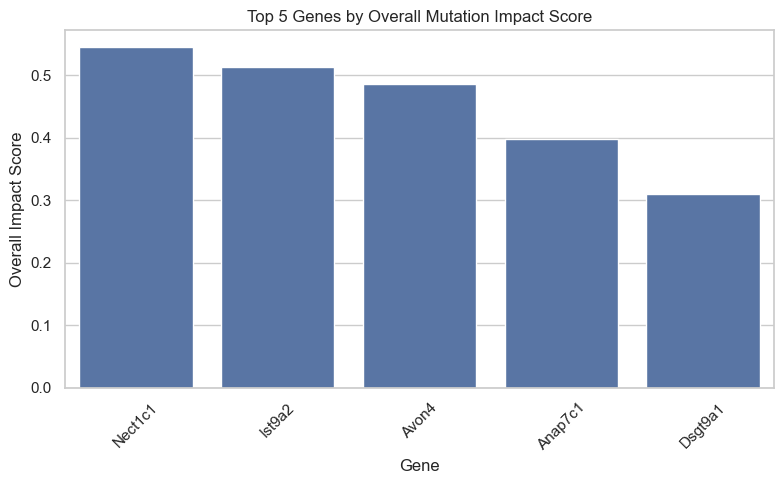

In [137]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=top5_genes,
    x="Gene",
    y="Overall.Impact.Score"
)

plt.title("Top 5 Genes by Overall Mutation Impact Score")
plt.xlabel("Gene")
plt.ylabel("Overall Impact Score")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

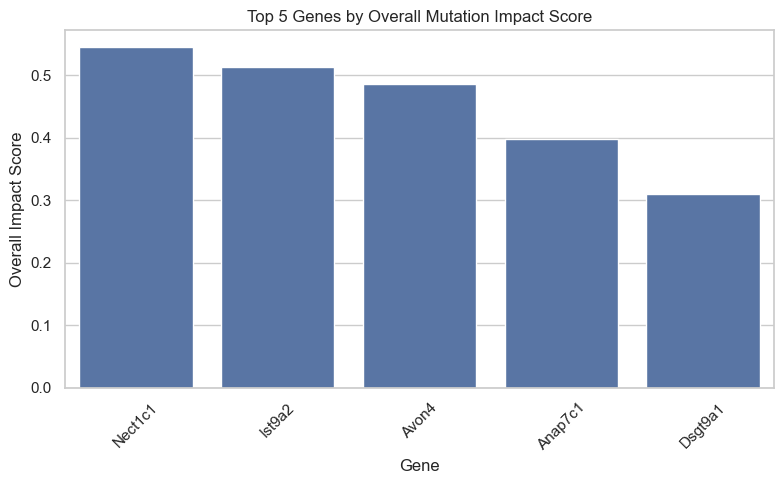

In [138]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=top5_genes,
    x="Gene",
    y="Overall.Impact.Score"
)

plt.title("Top 5 Genes by Overall Mutation Impact Score")
plt.xlabel("Gene")
plt.ylabel("Overall Impact Score")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("top5_overall_impact_score.png", dpi=300)
plt.show()

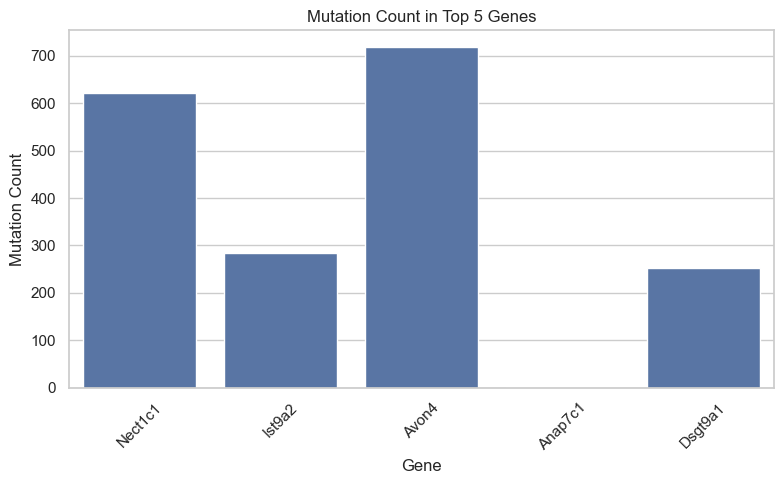

In [139]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=top5_genes,
    x="Gene",
    y="Mutation.Count"
)

plt.title("Mutation Count in Top 5 Genes")
plt.xlabel("Gene")
plt.ylabel("Mutation Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

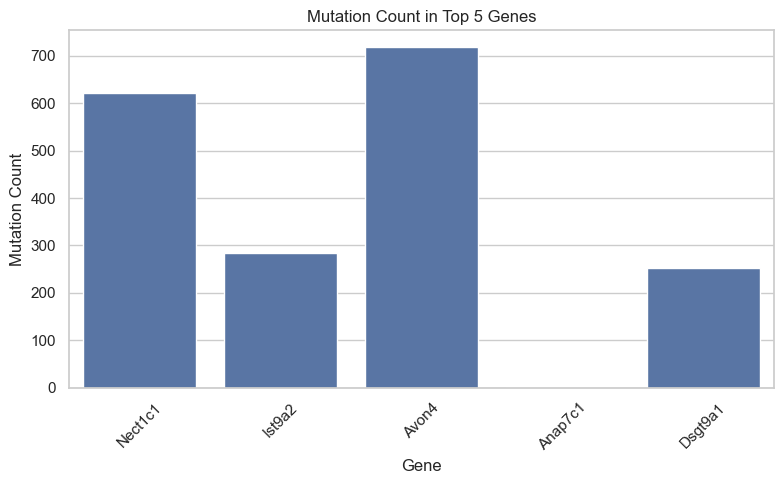

In [140]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=top5_genes,
    x="Gene",
    y="Mutation.Count"
)

plt.title("Mutation Count in Top 5 Genes")
plt.xlabel("Gene")
plt.ylabel("Mutation Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("top5_mutation_count.png", dpi=300)
plt.show()

In [141]:
foldchange_plot_df = top5_genes[
    [
        "Gene",
        "mRNA.FoldChange",
        "Protein.FoldChange",
        "Viability.FoldChange"
    ]
].copy()

foldchange_plot_df

,Gene,mRNA.FoldChange,Protein.FoldChange,Viability.FoldChange
20,Nect1c1,9.228777e-01,0.450044,15.773990
13,Ist9a2,4.475638e-09,0.000008,9.448663
4,Avon4,1.575283e+00,1.567175,9.122350
2,Anap7c1,-3.973853e+00,0.476239,0.000000
8,Dsgt9a1,1.099419e+00,1.901631,0.000000


In [142]:
foldchange_long_df = foldchange_plot_df.melt(
    id_vars="Gene",
    value_vars=[
        "mRNA.FoldChange",
        "Protein.FoldChange",
        "Viability.FoldChange"
    ],
    var_name="Measurement",
    value_name="FoldChange"
)

foldchange_long_df.head()

,Gene,Measurement,FoldChange
0,Nect1c1,mRNA.FoldChange,9.228777e-01
1,Ist9a2,mRNA.FoldChange,4.475638e-09
2,Avon4,mRNA.FoldChange,1.575283e+00
3,Anap7c1,mRNA.FoldChange,-3.973853e+00
4,Dsgt9a1,mRNA.FoldChange,1.099419e+00


In [143]:
foldchange_long_df["Measurement"] = foldchange_long_df["Measurement"].replace({
    "mRNA.FoldChange": "mRNA",
    "Protein.FoldChange": "Protein",
    "Viability.FoldChange": "Cell viability"
})

foldchange_long_df.head()

,Gene,Measurement,FoldChange
0,Nect1c1,mRNA,9.228777e-01
1,Ist9a2,mRNA,4.475638e-09
2,Avon4,mRNA,1.575283e+00
3,Anap7c1,mRNA,-3.973853e+00
4,Dsgt9a1,mRNA,1.099419e+00


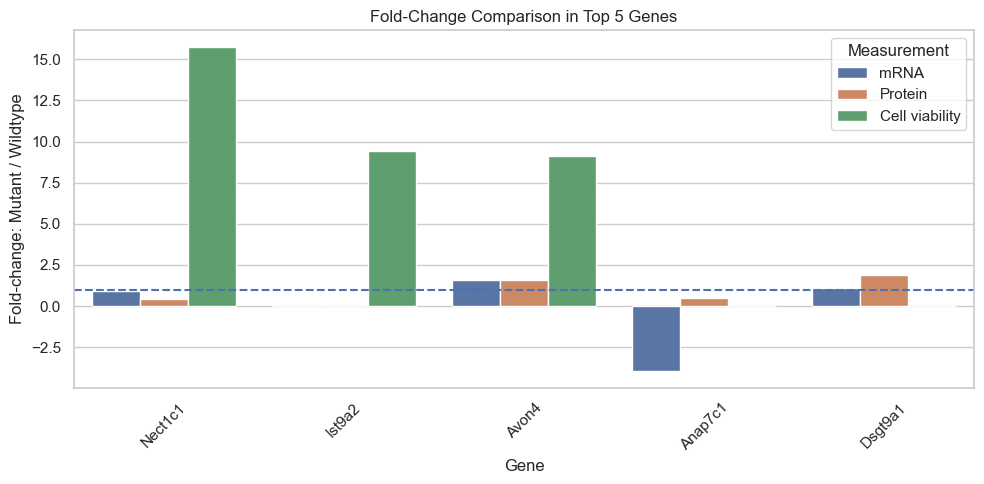

In [144]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=foldchange_long_df,
    x="Gene",
    y="FoldChange",
    hue="Measurement"
)

plt.axhline(1, linestyle="--")

plt.title("Fold-Change Comparison in Top 5 Genes")
plt.xlabel("Gene")
plt.ylabel("Fold-change: Mutant / Wildtype")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

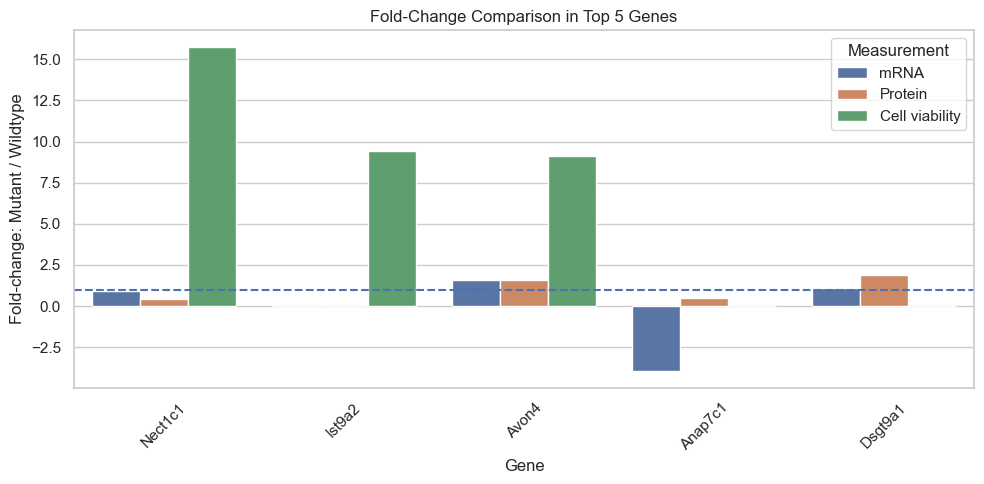

In [145]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=foldchange_long_df,
    x="Gene",
    y="FoldChange",
    hue="Measurement"
)

plt.axhline(1, linestyle="--")

plt.title("Fold-Change Comparison in Top 5 Genes")
plt.xlabel("Gene")
plt.ylabel("Fold-change: Mutant / Wildtype")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("top5_foldchange_comparison.png", dpi=300)
plt.show()

In [146]:
heatmap_df = top5_genes[
    [
        "Gene",
        "Mutation.Count.Normalised",
        "mRNA.Effect.Normalised",
        "Protein.Effect.Normalised",
        "Viability.Effect.Normalised"
    ]
].copy()

heatmap_df

,Gene,Mutation.Count.Normalised,mRNA.Effect.Normalised,Protein.Effect.Normalised,Viability.Effect.Normalised
20,Nect1c1,0.613031,0.015506,0.549961,1.000000
13,Ist9a2,0.280355,0.201051,1.000000,0.571861
4,Avon4,0.708786,0.115661,0.567179,0.549774
2,Anap7c1,0.000987,1.000000,0.523766,0.067687
8,Dsgt9a1,0.248766,0.019988,0.901638,0.067687


In [147]:
heatmap_df = heatmap_df.set_index("Gene")

heatmap_df

,Mutation.Count.Normalised,mRNA.Effect.Normalised,Protein.Effect.Normalised,Viability.Effect.Normalised
Gene,,,,
Nect1c1,0.613031,0.015506,0.549961,1.000000
Ist9a2,0.280355,0.201051,1.000000,0.571861
Avon4,0.708786,0.115661,0.567179,0.549774
Anap7c1,0.000987,1.000000,0.523766,0.067687
Dsgt9a1,0.248766,0.019988,0.901638,0.067687


In [148]:
heatmap_df = heatmap_df.rename(columns={
    "Mutation.Count.Normalised": "Mutation count",
    "mRNA.Effect.Normalised": "mRNA effect",
    "Protein.Effect.Normalised": "Protein effect",
    "Viability.Effect.Normalised": "Viability effect"
})

heatmap_df

,Mutation count,mRNA effect,Protein effect,Viability effect
Gene,,,,
Nect1c1,0.613031,0.015506,0.549961,1.000000
Ist9a2,0.280355,0.201051,1.000000,0.571861
Avon4,0.708786,0.115661,0.567179,0.549774
Anap7c1,0.000987,1.000000,0.523766,0.067687
Dsgt9a1,0.248766,0.019988,0.901638,0.067687


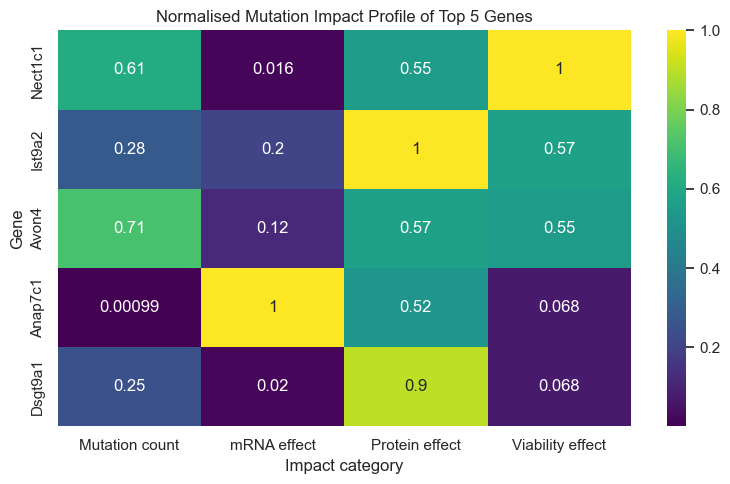

In [149]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    heatmap_df,
    annot=True,
    cmap="viridis"
)

plt.title("Normalised Mutation Impact Profile of Top 5 Genes")
plt.xlabel("Impact category")
plt.ylabel("Gene")

plt.tight_layout()
plt.show()

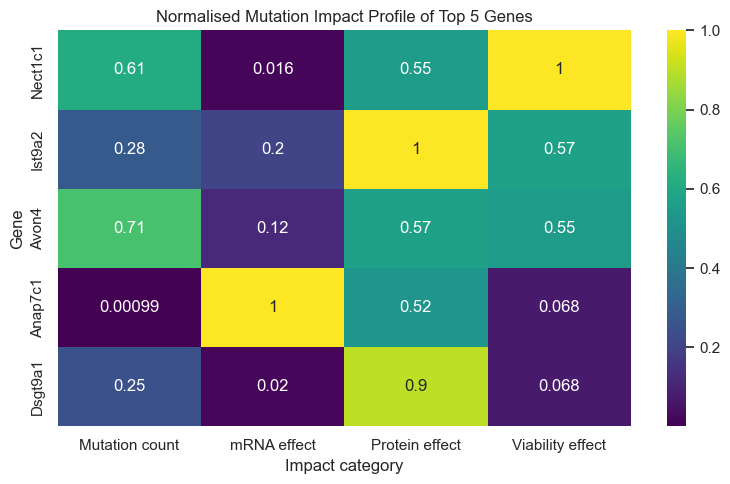

In [150]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    heatmap_df,
    annot=True,
    cmap="viridis"
)

plt.title("Normalised Mutation Impact Profile of Top 5 Genes")
plt.xlabel("Impact category")
plt.ylabel("Gene")

plt.tight_layout()
plt.savefig("top5_impact_heatmap.png", dpi=300)
plt.show()

In [151]:
from pathlib import Path

plot_files = list(Path(".").glob("*.png"))

for file in plot_files:
    print(file.name)

top5_foldchange_comparison.png
top5_impact_heatmap.png
top5_mutation_count.png
top5_overall_impact_score.png
